#  Tech Assessment: Weather Trend Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

In [2]:
# read csv
df = pd.read_csv("./data/GlobalWeatherRepository.csv")
print(df.shape)
df.sample(5)

(130003, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
43501,Armenia,Yerevan,40.1811,44.5136,Asia/Yerevan,1735293600,2024-12-27 14:00,4.1,39.4,Light rain,...,26.085,31.08,2,3,08:23 AM,05:43 PM,05:04 AM,02:39 PM,Waning Crescent,16
84083,Lithuania,Vilnius,54.6833,25.3167,Europe/Vilnius,1753260300,2025-07-23 11:45,18.2,64.8,Partly cloudy,...,4.995,6.66,1,1,05:14 AM,09:36 PM,02:30 AM,09:31 PM,Waning Crescent,5
40757,Uzbekistan,Tashkent,41.3167,69.2500,Asia/Tashkent,1734000300,2024-12-12 15:45,7.1,44.8,Sunny,...,53.280,55.87,3,6,07:40 AM,04:54 PM,02:20 PM,03:58 AM,Waxing Gibbous,83
14953,Ghana,Accra,5.5500,-0.2200,Africa/Accra,1722600900,2024-08-02 12:15,25.5,78.0,Patchy rain nearby,...,3.300,11.30,1,1,05:57 AM,06:17 PM,04:05 AM,04:56 PM,Waning Crescent,6
105612,United Arab Emirates,Abu Dhabi,24.4667,54.3667,Asia/Dubai,1762760700,2025-11-10 11:45,29.2,84.6,Sunny,...,46.150,56.15,3,5,06:35 AM,05:38 PM,10:31 PM,11:40 AM,Waning Gibbous,75


In [3]:
# display df stats
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,130003.000000,130003.000000,1.300030e+05,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,...,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000
mean,19.203631,21.976354,1.744777e+09,21.404561,70.529999,8.042931,12.947448,168.959509,1014.097521,29.945664,...,18.295989,468.990972,58.452398,15.142142,10.531454,24.463289,48.967420,1.706922,2.625162,49.725629
std,24.420627,65.788604,1.669083e+07,9.688223,17.438649,7.297507,11.741068,103.572696,10.497520,0.309957,...,13.922968,769.933810,30.962557,23.987244,36.312698,37.398961,151.004804,0.946519,2.461476,35.020085
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.870000,-6.836100,1.730365e+09,16.100000,61.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.300000,207.200000,38.000000,1.665000,1.100000,7.150000,10.000000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.744794e+09,24.000000,75.300000,6.900000,11.200000,161.000000,1014.000000,29.930000,...,15.400000,299.700000,55.100000,5.550000,2.405000,14.245000,20.165000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.759219e+09,28.000000,82.400000,11.000000,17.600000,255.000000,1018.000000,30.060000,...,24.300000,467.300000,74.000000,17.575000,8.510000,28.050000,41.950000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.773730e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [4]:
# display all columns
df.columns.values.tolist()

['country',
 'location_name',
 'latitude',
 'longitude',
 'timezone',
 'last_updated_epoch',
 'last_updated',
 'temperature_celsius',
 'temperature_fahrenheit',
 'condition_text',
 'wind_mph',
 'wind_kph',
 'wind_degree',
 'wind_direction',
 'pressure_mb',
 'pressure_in',
 'precip_mm',
 'precip_in',
 'humidity',
 'cloud',
 'feels_like_celsius',
 'feels_like_fahrenheit',
 'visibility_km',
 'visibility_miles',
 'uv_index',
 'gust_mph',
 'gust_kph',
 'air_quality_Carbon_Monoxide',
 'air_quality_Ozone',
 'air_quality_Nitrogen_dioxide',
 'air_quality_Sulphur_dioxide',
 'air_quality_PM2.5',
 'air_quality_PM10',
 'air_quality_us-epa-index',
 'air_quality_gb-defra-index',
 'sunrise',
 'sunset',
 'moonrise',
 'moonset',
 'moon_phase',
 'moon_illumination']

# Basic Assessment

## Data Cleaning & Preprocessing
* Handle missing values
* outliers
* normalize data

### Missing Values

In [5]:
# Handle missing values
missing_count = df.isnull().sum()

print("Missing values per column")
missing_count[missing_count > 0]

# if missing values, either drop rows with them / replace missing values with mean, median or relevant mode / fill missing values with closest values in column / interpolation technique 

Missing values per column


Series([], dtype: int64)

!!! NO MISSING VALUES

### Outliers
* Outliers that may vary - be careful
    * tmp, humidity, pressure, wind, UV, precipitation 
    * condition text, wind direction, air quality indices
* extreme real event vs real outlier

In [6]:
# IQR DOES NOT WORK (24,163 outliers)
# Hard limit based on meteorology like max and min celsius known
# Z-score with high threshold 3 or 4?

domain_limits = {
    'temperature_celsius': (-85, 55),  # record low ~ -89.2, high ~ 56.7
    'wind_kph': (0, 408),              # world record wind kph ~408 kph
    'pressure_mb': (870, 1085),        # lows (typhoons) ~870, highs ~1085
    'precip_mm': (0, 1400)             # daily rainfall record ~1825
}

df_original = df.copy()

for col in ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm']:
    # domain clipping 
    lower, upper = domain_limits[col]
    df[col] = df[col].clip(lower=lower, upper=upper)
    
    # z socre clipping 3
    mean = df[col].mean()
    std = df[col].std()
    
    z_upper = mean + 3 * std
    z_lower = mean - 3 * std
    
    # how many are changed
    z_outliers = df[(df[col] < z_lower) | (df[col] > z_upper)].shape[0]
    print(f"{col}: Clipped {z_outliers} statistical outliers (Z > 3).")
    
    # apply clipping
    df[col] = df[col].clip(lower=z_lower, upper=z_upper)

plt.tight_layout()
plt.show()


temperature_celsius: Clipped 954 statistical outliers (Z > 3).
wind_kph: Clipped 1103 statistical outliers (Z > 3).
pressure_mb: Clipped 1090 statistical outliers (Z > 3).
precip_mm: Clipped 1841 statistical outliers (Z > 3).


<Figure size 640x480 with 0 Axes>

In [7]:
# check stats
stats_check = []
for col in ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm']:
    mean = df[col].mean()
    std = df[col].std()
    stats_check.append({
        'Feature': col,
        'Mean': round(mean, 2),
        'Std Dev': round(std, 2),
        'Lower Bound (Mean - 3σ)': round(mean - 3*std, 2),
        'Upper Bound (Mean + 3σ)': round(mean + 3*std, 2),
        'Max Value': df[col].max()
    })

pd.DataFrame(stats_check)

,Feature,Mean,Std Dev,Lower Bound (Mean - 3σ),Upper Bound (Mean + 3σ),Max Value
0,temperature_celsius,21.45,9.54,-7.17,50.06,49.200000
1,wind_kph,12.87,8.15,-11.57,37.32,38.401315
2,pressure_mb,1014.08,6.86,993.50,1034.66,1035.157342
3,precip_mm,0.11,0.33,-0.86,1.09,1.827423


### Normalize Data
* differente scales for data
* XGBoost + LSTM? + Sarimax for seasonality
* XGBoost - NO normalization need (tree based)
* LSTM/SARIMAX - Standard Z-score normalization 

In [8]:
# time sorting
df = df.sort_values('last_updated')

# data split 80 / 20
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# feat to scale
cols_to_scale = ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity']

# log transform precip_mm before scaling (too skewed)
train_df['precip_mm'] = np.log1p(train_df['precip_mm'])
test_df['precip_mm'] = np.log1p(test_df['precip_mm'])

# fit on train, transform on both
scaler = StandardScaler()
train_df[cols_to_scale] = scaler.fit_transform(train_df[cols_to_scale])
test_df[cols_to_scale] = scaler.transform(test_df[cols_to_scale])

print(f"Split complete. Train set: {train_df.shape[0]} rows | Test set: {test_df.shape[0]} rows")

Split complete. Train set: 104002 rows | Test set: 26001 rows


## Exploratory Data Analysis (EDA)

### Perform basic EDA to uncover the trends, correlations, and patterns.
* feature relationship
* autocorr (ACF) and partial autocorr (PACF)
* spearman heatmap - non linear relation -
* decompose target var into its trend
* Plotting rolling means/standard deviations and performing the Augmented Dickey-Fuller (ADF) test - SARIMAX requires data to be stationary

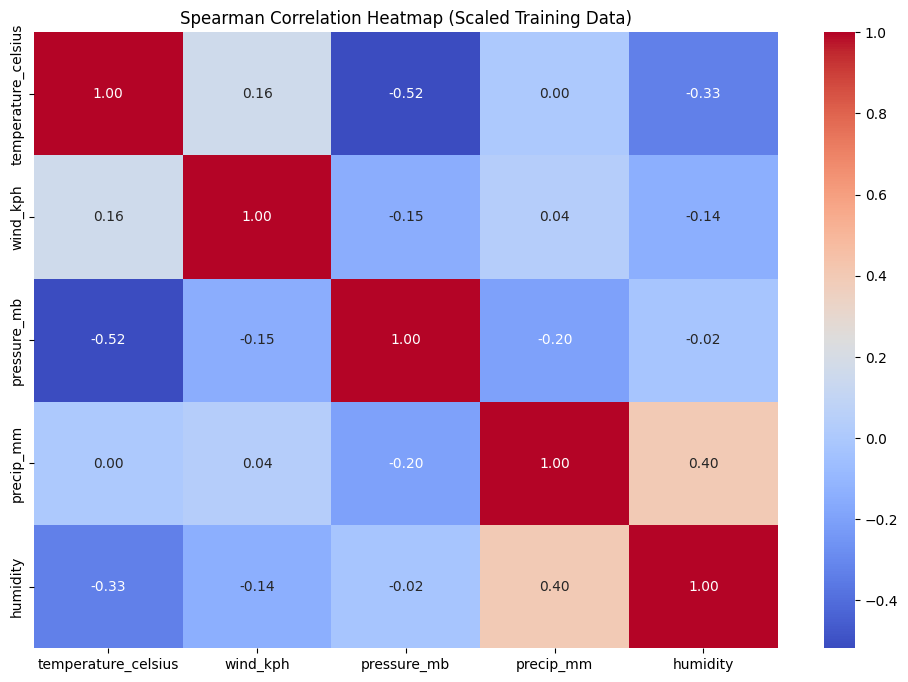

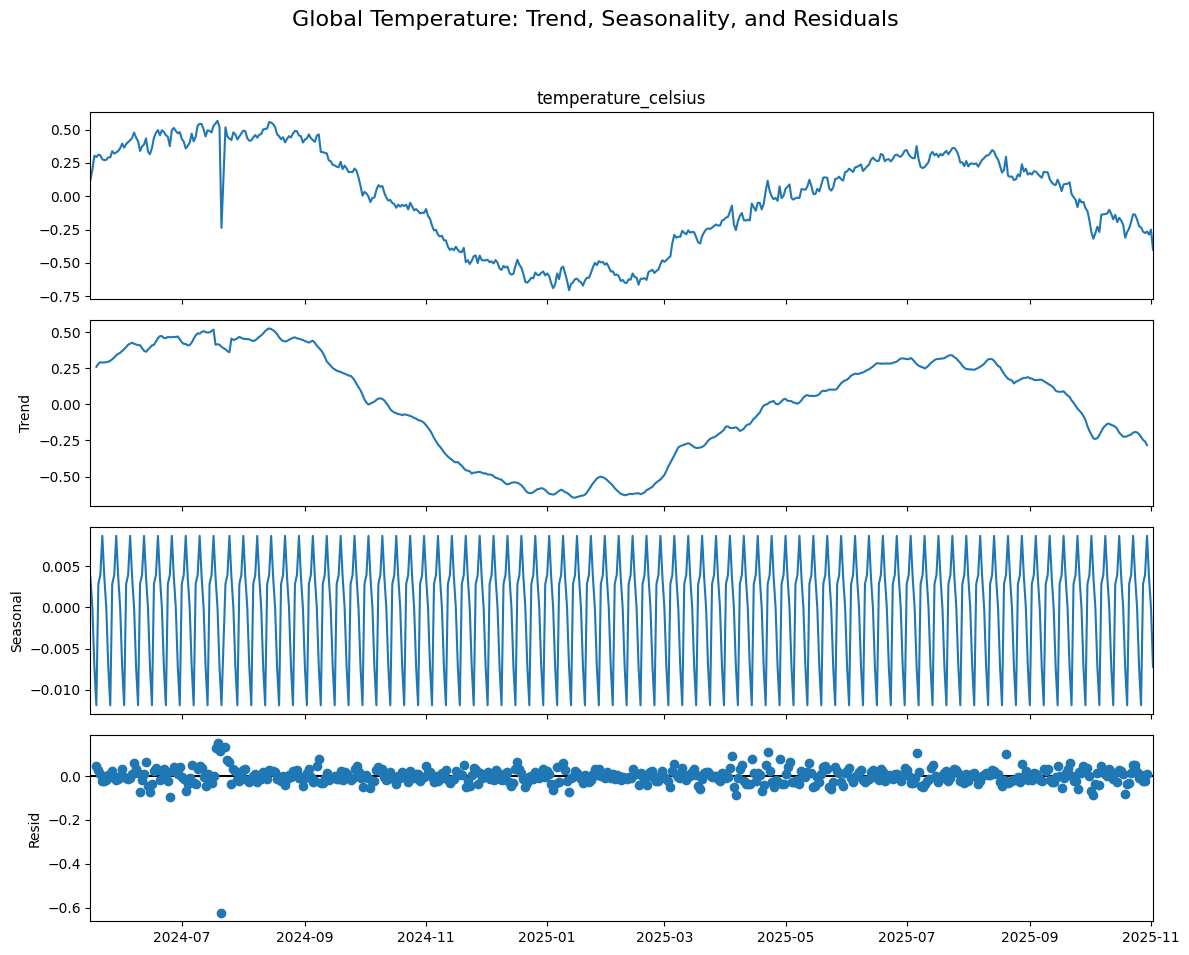

In [9]:

# Heatmap for Feature Relationships
plt.figure(figsize=(12, 8))
# spearman relation since weather relations are not linear
correlation_matrix = train_df[cols_to_scale].corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap (Scaled Training Data)")
plt.show()

# ensure column is datetime
train_df['last_updated'] = pd.to_datetime(train_df['last_updated'])

# set index and cast to DatetimeIndex (prevent pandas indexing error)
temp_series = train_df.set_index('last_updated')['temperature_celsius']
temp_series.index = pd.DatetimeIndex(temp_series.index)

# resample to daily mean and drop nans it could create
daily_temp = temp_series.resample('D').mean().dropna()

# Seasonal Decomposition
# typically weekly or yearly seasonality for weather
# stick with 7 for a short-term trend.


decomposition = seasonal_decompose(daily_temp, model='additive', period=7)

# plot
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Global Temperature: Trend, Seasonality, and Residuals', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

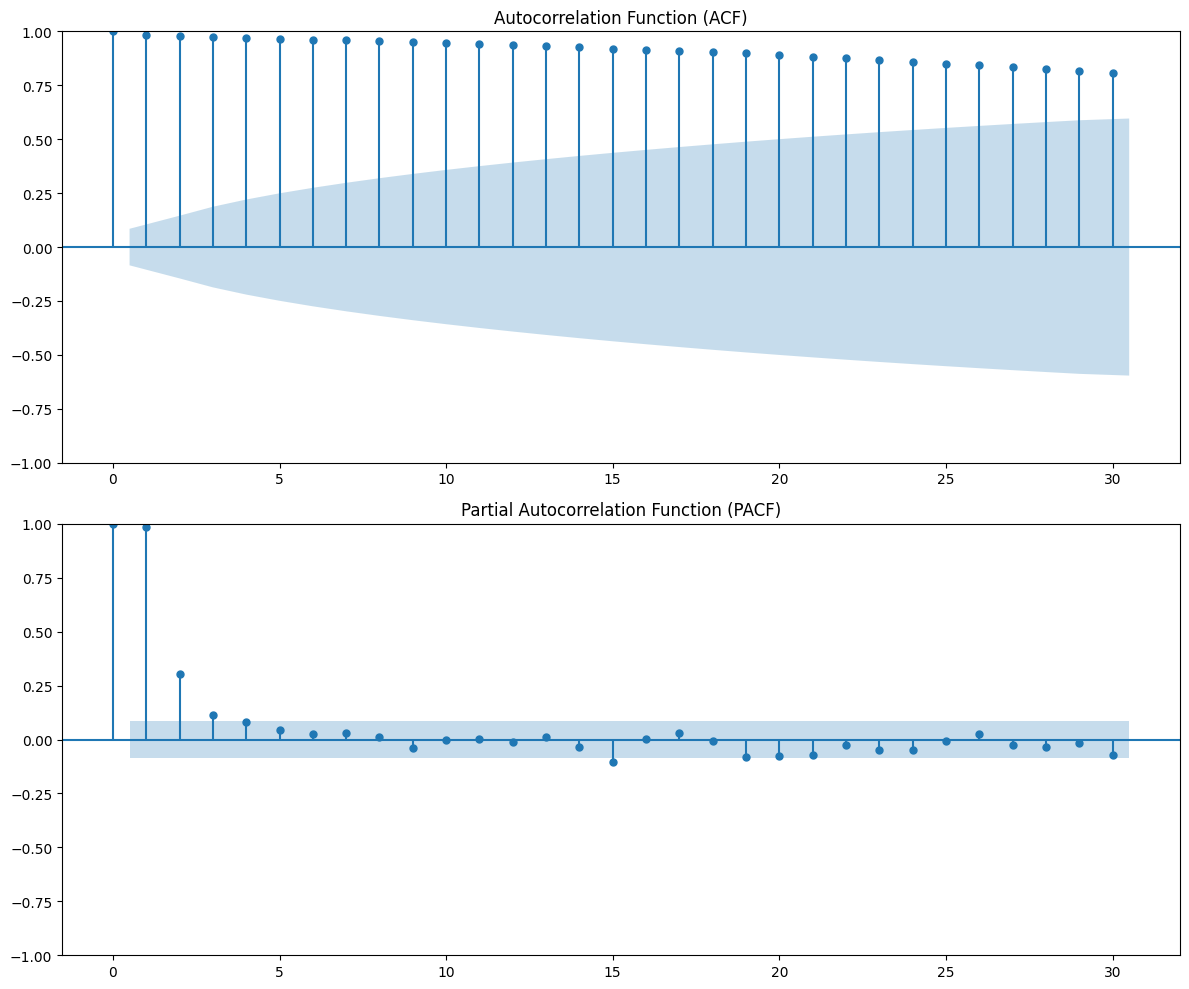

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF
plot_acf(daily_temp, lags=30, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# PACF
plot_pacf(daily_temp, lags=30, ax=ax2, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

* Strong trend in the data
* todays weahter high correlated with yestearday, before, and so on
* Suggests Auto-Regressive (AR) process
* Almost all predictive power comes from the 1-2 days

### Visualization for temperature and precipitation
* boxplot of temp/precipitaion by continent or region

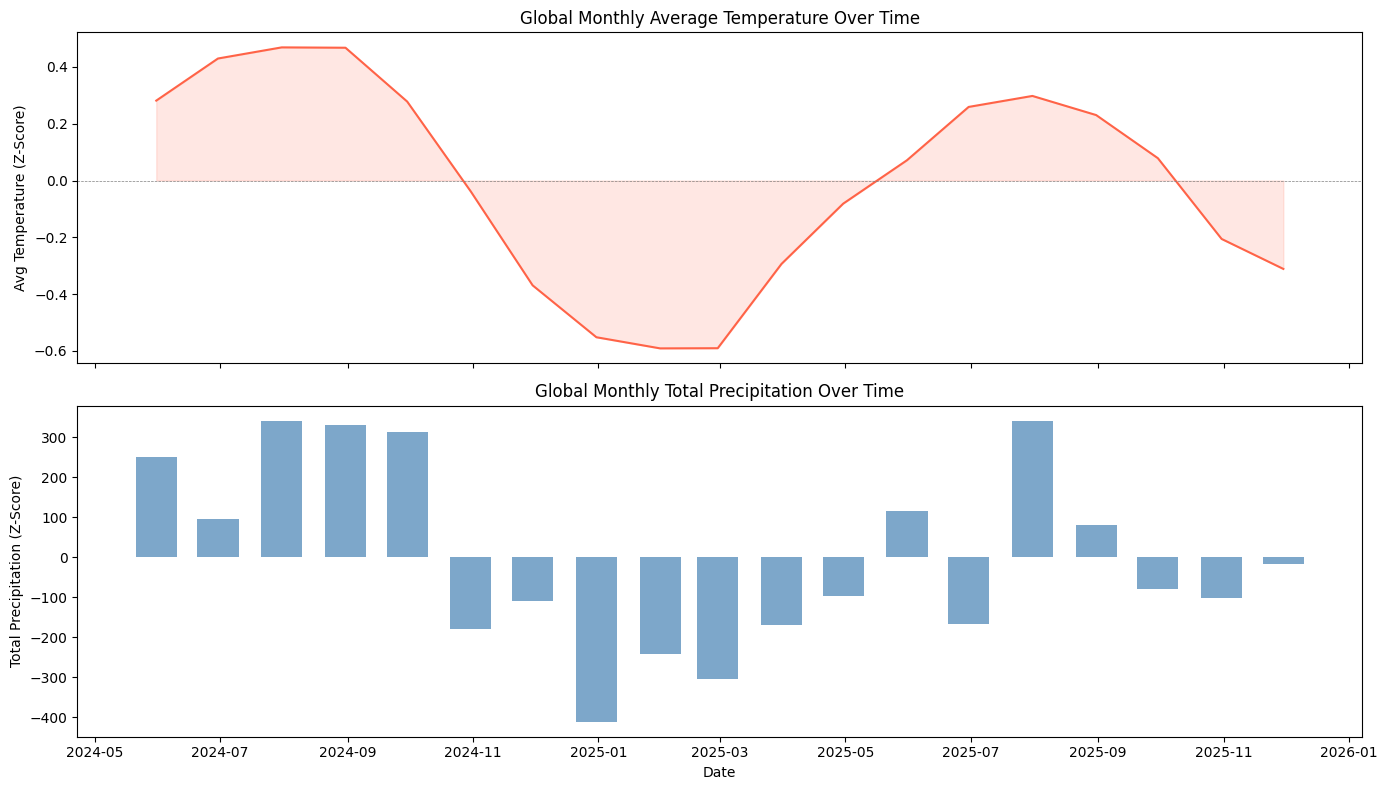

In [11]:
# --- Temperature: monthly mean over time ---
train_df['last_updated'] = pd.to_datetime(train_df['last_updated'])
monthly = train_df.set_index('last_updated').resample('ME').agg(
    temp_mean=('temperature_celsius', 'mean'),
    precip_sum=('precip_mm', 'sum')
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Temperature trend
ax1.plot(monthly['last_updated'], monthly['temp_mean'], color='tomato', linewidth=1.5)
ax1.fill_between(monthly['last_updated'], monthly['temp_mean'], alpha=0.15, color='tomato')
ax1.set_ylabel('Avg Temperature (Z-Score)')
ax1.set_title('Global Monthly Average Temperature Over Time')
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Precipitation trend
ax2.bar(monthly['last_updated'], monthly['precip_sum'], color='steelblue',
        width=20, alpha=0.7)
ax2.set_ylabel('Total Precipitation (Z-Score)')
ax2.set_title('Global Monthly Total Precipitation Over Time')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

## Model Building

### Build a basic forecasting model and evaluate its performance using different metrics.
* Final planned model: XGBoost + LSTM + SARIMAX
    * START with XGBoost

* target var: temperature_celsius - Regression Task
* XGBoost dont handle sequence 
    * create 'lag features' to simulate it. 1, 2, 3, 7 (yesterday, 2 days ago, week ago)
* aggregate daily global mean (daily_temp)
* target is scaled (z-scored). INVERSE it to better human interpretability 

In [12]:


# daily global mean series (scaled)
train_df['last_updated'] = pd.to_datetime(train_df['last_updated'])
test_df['last_updated']  = pd.to_datetime(test_df['last_updated'])

daily_train = (train_df.set_index('last_updated')['temperature_celsius'].resample('D').mean().dropna().rename('temp'))

daily_test  = (test_df.set_index('last_updated')['temperature_celsius'].resample('D').mean().dropna().rename('temp'))



In [13]:
# lag and rolling window feature
def make_features(series: pd.Series) -> pd.DataFrame:
    df_feat = series.to_frame()
    for lag in [1, 2, 3, 7]:
        df_feat[f'lag_{lag}'] = df_feat['temp'].shift(lag)
    for window in [3, 7]:
        df_feat[f'roll_mean_{window}'] = df_feat['temp'].shift(1).rolling(window).mean()
        df_feat[f'roll_std_{window}']  = df_feat['temp'].shift(1).rolling(window).std()
    df_feat['day_of_week'] = df_feat.index.dayofweek
    df_feat['month']       = df_feat.index.month
    df_feat = df_feat.dropna()        # drop rows where lags are undefined
    return df_feat

train_feat = make_features(daily_train)
test_feat  = make_features(daily_test)

FEATURE_COLS = [c for c in train_feat.columns if c != 'temp']
TARGET        = 'temp'

X_train, y_train = train_feat[FEATURE_COLS], train_feat[TARGET]
X_test,  y_test  = test_feat[FEATURE_COLS],  test_feat[TARGET]

print(f"Train features: {X_train.shape} | Test features: {X_test.shape}")

Train features: (528, 10) | Test features: (129, 10)


In [14]:
# training model
xgb_model = xgb.XGBRegressor(
    n_estimators       = 500,
    learning_rate      = 0.05,
    max_depth          = 4,          # shallow trees → less overfit on small daily series
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    random_state       = 42,
    early_stopping_rounds = 30,
    eval_metric        = 'rmse',
    verbosity          = 0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"Best iteration: {xgb_model.best_iteration}")

Best iteration: 188


In [15]:
# predict and inverse transform
TEMP_IDX = cols_to_scale.index('temperature_celsius')   # position in scaler

def inverse_temp(scaled_vals):
    dummy = np.zeros((len(scaled_vals), len(cols_to_scale)))
    dummy[:, TEMP_IDX] = scaled_vals
    return scaler.inverse_transform(dummy)[:, TEMP_IDX]

y_pred_scaled = xgb_model.predict(X_test)

y_pred_celsius = inverse_temp(y_pred_scaled)
y_test_celsius = inverse_temp(y_test.values)

In [16]:
# evaluatiaon
mae  = mean_absolute_error(y_test_celsius, y_pred_celsius)
rmse = np.sqrt(mean_squared_error(y_test_celsius, y_pred_celsius))
r2   = r2_score(y_test_celsius, y_pred_celsius)
mape = np.mean(np.abs((y_test_celsius - y_pred_celsius) /
                       np.where(y_test_celsius == 0, 1e-8, y_test_celsius))) * 100

metrics_xgb = {'MAE (°C)': round(mae, 3),
               'RMSE (°C)': round(rmse, 3),
               'R²': round(r2, 4),
               'MAPE (%)': round(mape, 2)}

print("\n── XGBoost Forecast Metrics ──")
for k, v in metrics_xgb.items():
    print(f"  {k}: {v}")


── XGBoost Forecast Metrics ──
  MAE (°C): 1.172
  RMSE (°C): 1.809
  R²: -0.3643
  MAPE (%): 9.56


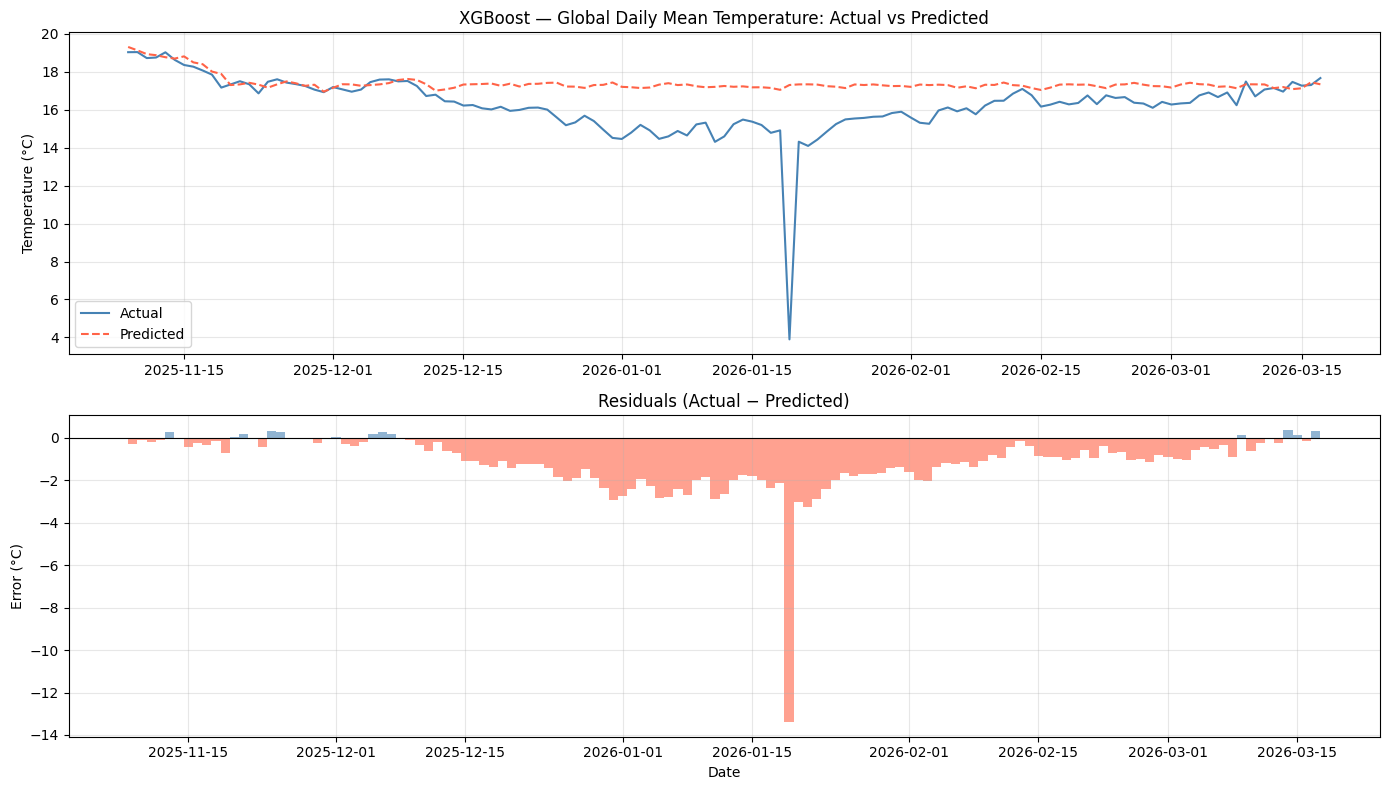

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1 — time series overlay
ax1.plot(test_feat.index, y_test_celsius,  label='Actual',    color='steelblue',  linewidth=1.5)
ax1.plot(test_feat.index, y_pred_celsius,  label='Predicted', color='tomato',     linewidth=1.5, linestyle='--')
ax1.set_title('XGBoost — Global Daily Mean Temperature: Actual vs Predicted')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2 — residuals
residuals = y_test_celsius - y_pred_celsius
ax2.bar(test_feat.index, residuals, color=np.where(residuals >= 0, 'steelblue', 'tomato'),
        alpha=0.6, width=1)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Residuals (Actual − Predicted)')
ax2.set_ylabel('Error (°C)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()